# GitPet Sprite Viewer
이 노트북은 `src/sprites/traits` 에 생성된 20종의 픽셀 아트(JSON 포맷)를 시각화하여 확인하기 위한 스크립트입니다.
`matplotlib` 패키지가 설치되어 있어야 합니다. (`pip install matplotlib`)

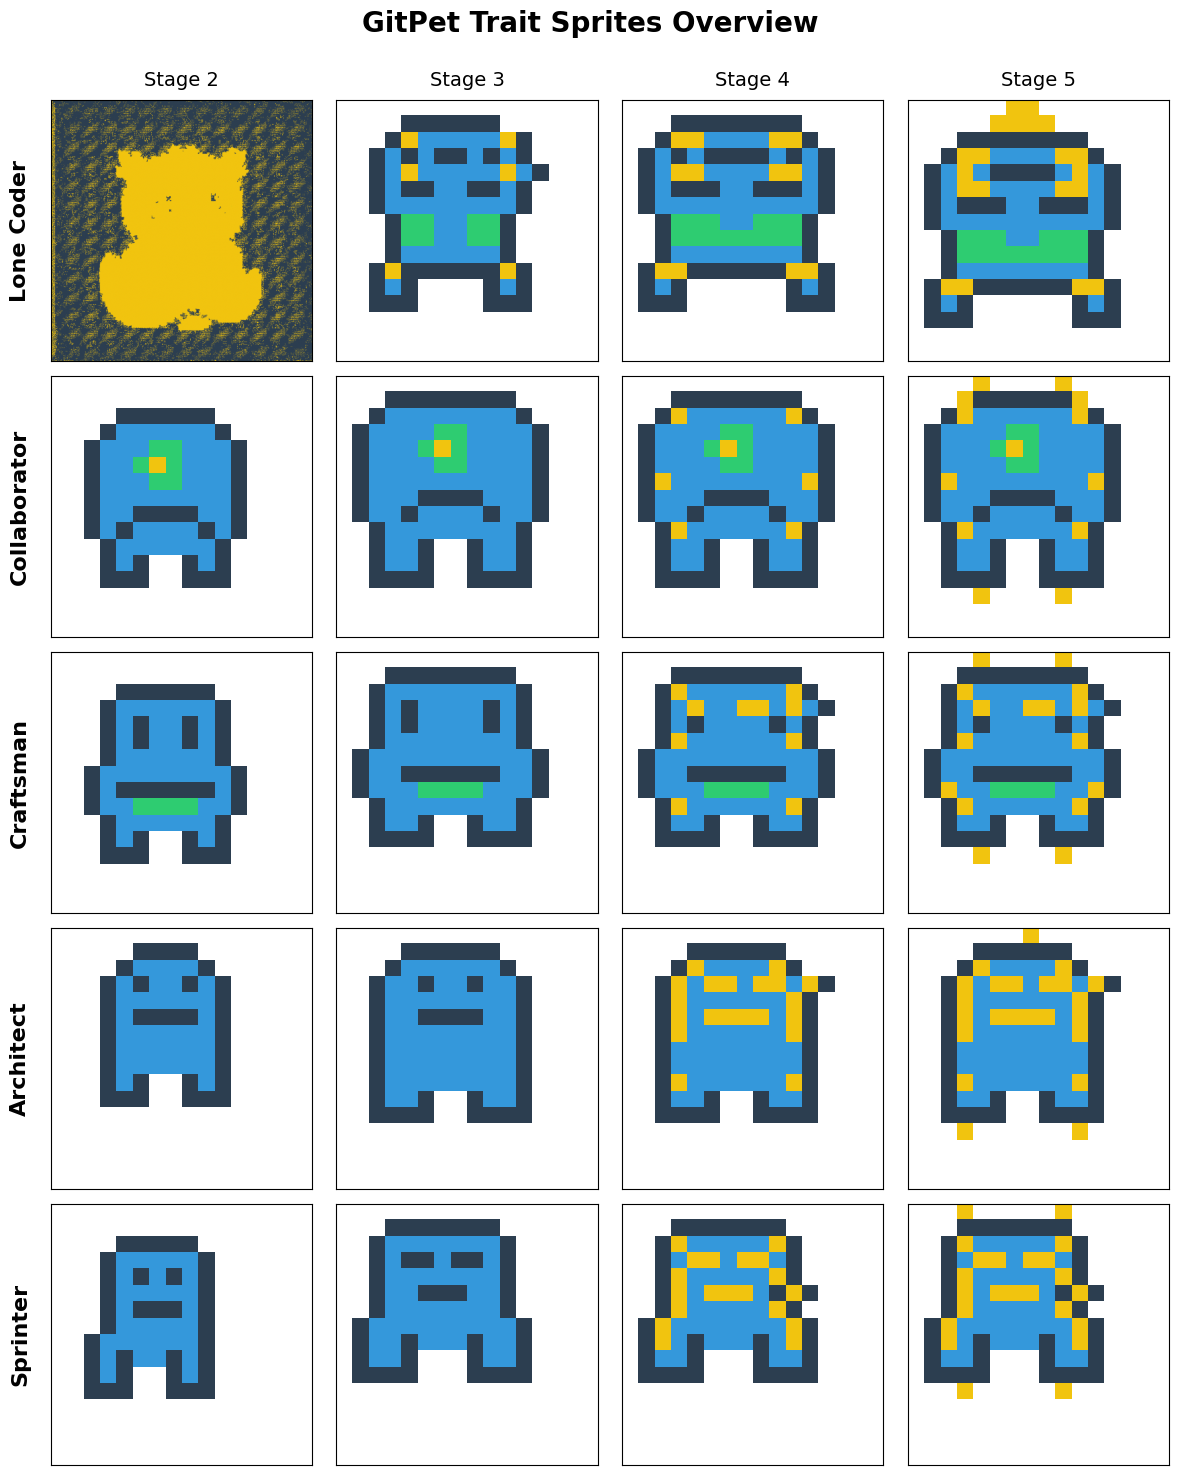

In [1]:
import json
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 팔레트 컬러 정의 (0: 투명, 1: 윤곽선, 2: 프라이머리, 3: 세컨더리, 4: 하이라이트)
colors = ['#ffffff', '#2c3e50', '#3498db', '#2ecc71', '#f1c40f']
cmap = ListedColormap(colors)

traits = ['lone_coder', 'collaborator', 'craftsman', 'architect', 'sprinter']
stages = [2, 3, 4, 5]

fig, axes = plt.subplots(len(traits), len(stages), figsize=(12, 15))
fig.suptitle('GitPet Trait Sprites Overview', fontsize=20, fontweight='bold')

base_dir = 'src/sprites/traits'

for i, trait in enumerate(traits):
    for j, stage in enumerate(stages):
        ax = axes[i, j]
        file_path = os.path.join(base_dir, f'{trait}_stage{stage}.json')
        
        if os.path.exists(file_path):
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                frame = data['frames']['default']
                ax.imshow(frame, cmap=cmap, vmin=0, vmax=4)
        else:
            ax.text(0.5, 0.5, 'Missing', ha='center', va='center', color='red')
            ax.set_facecolor('#f0f0f0')
            
        # 축 눈금 제거
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 레이블 설정
        if i == 0:
            ax.set_title(f'Stage {stage}', fontsize=14, pad=10)
        if j == 0:
            ax.set_ylabel(trait.replace('_', ' ').title(), size=16, labelpad=15, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()
